In [2]:
import pandas as pd
import stylia
import matplotlib.pyplot as plt

# Format: slide | Style: ersilia — change with stylia.set_format() / stylia.set_style()
stylia.set_format("slide")
stylia.set_style("ersilia")

datapath = "../output/mtuberculosis"

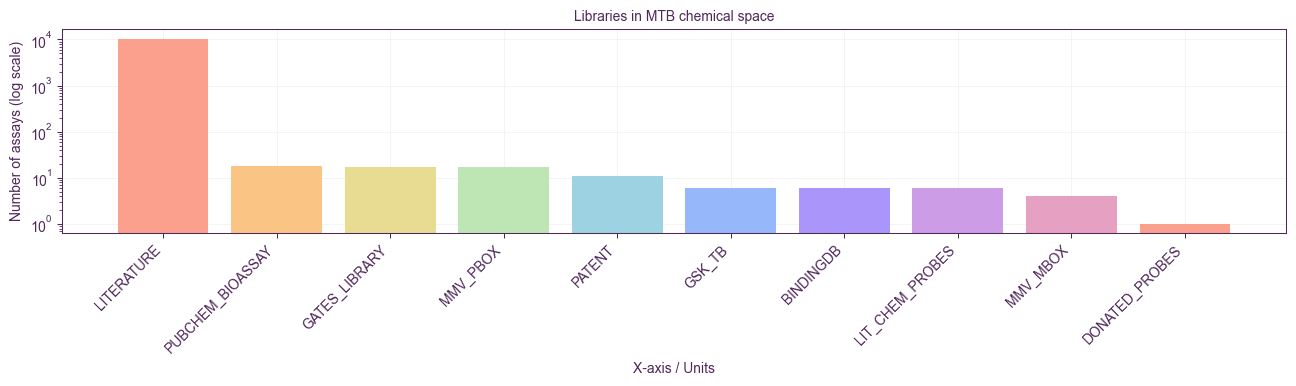

In [3]:
# Number of assays per source library in the MTB chemical space
df = pd.read_csv(f"{datapath}/18_assays_master.csv")
counts = df["source_label"].value_counts().sort_values(ascending=False)

cm = stylia.CyclicColormap("ersilia")
cm.fit(list(range(len(counts))))
colors = cm.transform(list(range(len(counts))))

fig, axs = stylia.create_figure(1, 1)
ax = axs.next()
ax.bar(range(len(counts)), counts.values, color=colors)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=45, ha="right")
ax.set_yscale("log")
stylia.label(ax, ylabel="Number of assays (log scale)", title="Libraries in MTB chemical space")
plt.show()

In [4]:
# Unique compounds per source library (deduplication by compound_chembl_id on standardised molecules)
import os

master = pd.read_csv(f"{datapath}/18_assays_master.csv", usecols=["assay_id", "source_label"])
acts = pd.read_csv(f"{datapath}/08_chembl_cleaned_data.csv.gz", usecols=["assay_chembl_id", "compound_chembl_id", "smiles"])

# Join on assay identifier
merged = acts.merge(master, left_on="assay_chembl_id", right_on="assay_id", how="inner")

# Save per-library compound lists to /tmp for reuse
os.makedirs("/tmp/mtb_libraries", exist_ok=True)
lib_counts = {}
for label, grp in merged.groupby("source_label"):
    unique = grp.drop_duplicates(subset="compound_chembl_id")[["compound_chembl_id", "smiles"]]
    unique.to_csv(f"/tmp/mtb_libraries/{label}.csv", index=False)
    lib_counts[label] = len(unique)

# Table
lib_table = pd.DataFrame(lib_counts.items(), columns=["source_label", "n_compounds_unique"])
lib_table = lib_table.sort_values("n_compounds_unique", ascending=False).reset_index(drop=True)
print(lib_table.to_string(index=False))

    source_label  n_compounds_unique
   GATES_LIBRARY               86616
      LITERATURE               40166
PUBCHEM_BIOASSAY                8343
          GSK_TB                 826
        MMV_MBOX                 399
       BINDINGDB                 193
          PATENT                 119
        MMV_PBOX                 116
  DONATED_PROBES                 108
 LIT_CHEM_PROBES                   9


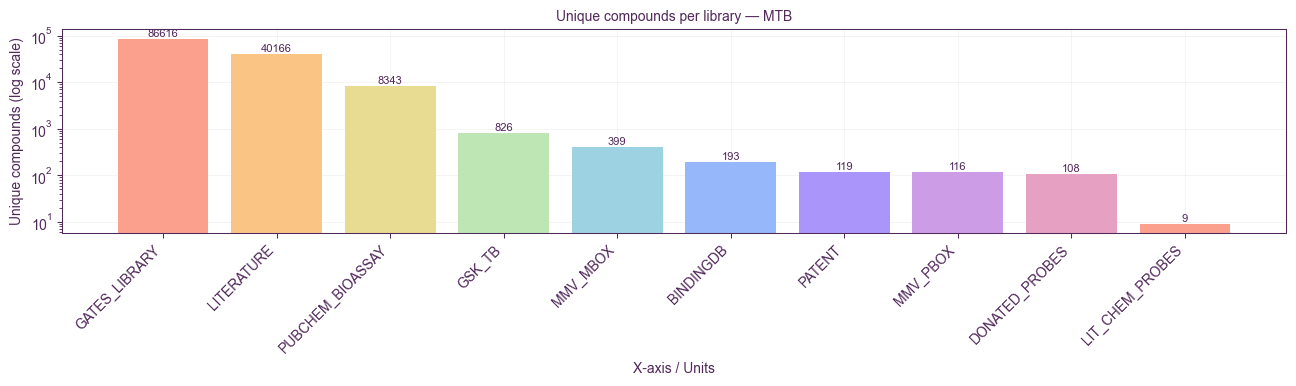

In [5]:
# Bar plot — unique compounds per source library (log scale)
counts = lib_table.set_index("source_label")["n_compounds_unique"]

cm = stylia.CyclicColormap("ersilia")
cm.fit(list(range(len(counts))))
colors = cm.transform(list(range(len(counts))))

fig, axs = stylia.create_figure(1, 1)
ax = axs.next()
ax.bar(range(len(counts)), counts.values, color=colors)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=45, ha="right")
ax.set_yscale("log")
for i, v in enumerate(counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=stylia.FONTSIZE_SMALL)
stylia.label(ax, ylabel="Unique compounds (log scale)", title="Unique compounds per library — MTB")
plt.show()

In [ ]:
import sys
import numpy as np
from umap import umap

sys.path.insert(0, os.path.join("..", "src"))
from model_utils import load_ecfp_subset_by_chembl_id

H5_PATH = "../data/chembl_processed/06_chembl_ecfps.h5"
UMAP_CACHE = "/tmp/mtb_libraries/umap_embedding.csv"

# Load all per-library compound lists and collect all unique MTB compounds
all_dfs = []
for label in lib_table["source_label"]:
    df = pd.read_csv(f"/tmp/mtb_libraries/{label}.csv")[["compound_chembl_id"]]
    df["source_label"] = label
    all_dfs.append(df)
all_cpds = (
    pd.concat(all_dfs)
    .drop_duplicates(subset="compound_chembl_id")
    .reset_index(drop=True)
)

# Load or compute and cache UMAP embedding
if os.path.exists(UMAP_CACHE):
    print("Loading cached UMAP embedding...")
    emb_df = pd.read_csv(UMAP_CACHE)
else:
    print("Loading ECFP6 fingerprints...")
    ecfps = load_ecfp_subset_by_chembl_id(H5_PATH, set(all_cpds["compound_chembl_id"]))
    valid_ids = [cid for cid in all_cpds["compound_chembl_id"] if cid in ecfps]
    X = np.array([ecfps[cid] for cid in valid_ids])
    print(f"Fitting UMAP on {len(valid_ids):,} compounds...")
    reducer = umap.UMAP(random_state=42)
    embedding = reducer.fit_transform(X)
    emb_df = pd.DataFrame({
        "compound_chembl_id": valid_ids,
        "umap1": embedding[:, 0],
        "umap2": embedding[:, 1],
    })
    emb_df.to_csv(UMAP_CACHE, index=False)
    print("Embedding saved to", UMAP_CACHE)

# Per-library membership sets
lib_sets = {
    label: set(pd.read_csv(f"/tmp/mtb_libraries/{label}.csv")["compound_chembl_id"])
    for label in lib_table["source_label"]
}

# Same color mapping as bar plot
labels_ordered = lib_table["source_label"].tolist()  # largest → smallest
cm_umap = stylia.CyclicColormap("ersilia")
cm_umap.fit(list(range(len(labels_ordered))))
colors_umap = cm_umap.transform(list(range(len(labels_ordered))))
color_map = dict(zip(labels_ordered, colors_umap))

# Plot: gray background, then large libraries first so small ones paint on top
fig, axs = stylia.create_figure(1, 1, width=0.5, height=0.5)
ax = axs.next()

ax.scatter(emb_df["umap1"], emb_df["umap2"], color="lightgray", alpha=0.3, rasterized=True)

for label in labels_ordered:  # largest first → smallest last (on top)
    mask = emb_df["compound_chembl_id"].isin(lib_sets[label])
    sub = emb_df[mask]
    ax.scatter(sub["umap1"], sub["umap2"], color=color_map[label], label=label, alpha=0.6, rasterized=True)

ax.legend()
stylia.label(ax, xlabel="UMAP 1", ylabel="UMAP 2", title="MTB chemical space by library (ECFP6)")
plt.show()

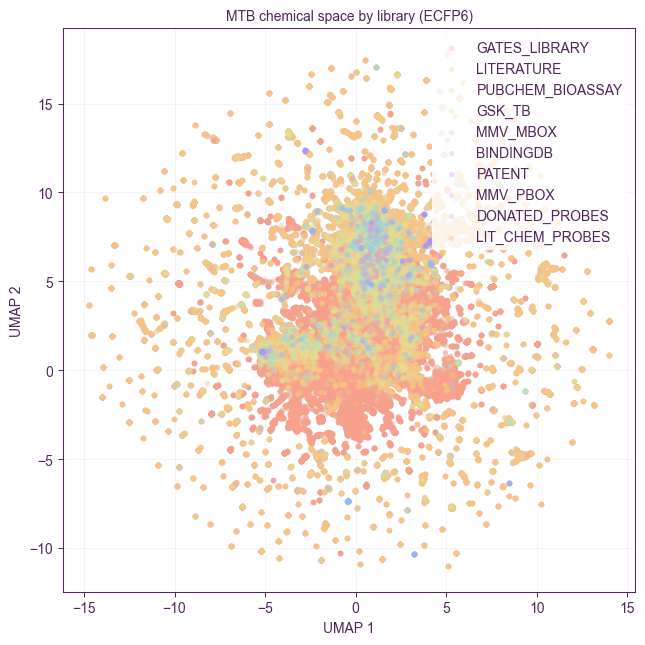

In [10]:
# Plot: gray background (all MTB space) + per-library overlay (large → small)
fig, axs = stylia.create_figure(1, 1, width=0.5, height=0.5)
ax = axs.next()

ax.scatter(emb_df["umap1"], emb_df["umap2"], color="lightgray", alpha=0.3, rasterized=True)
labels_ordered = lib_table["source_label"].tolist()  # largest → smallest
for label in labels_ordered:  # small libraries on top
    mask = emb_df["compound_chembl_id"].isin(lib_sets[label])
    sub = emb_df[mask]
    ax.scatter(sub["umap1"], sub["umap2"], color=color_map[label], label=label, alpha=0.3, rasterized=True)

ax.legend()
stylia.label(ax, xlabel="UMAP 1", ylabel="UMAP 2", title="MTB chemical space by library (ECFP6)")
plt.show()